<a href="https://colab.research.google.com/github/Snehayadawad/Machine-Learning/blob/main/machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
df = pd.read_csv("/content/student_performance (1).csv")
df

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A
...,...,...,...,...,...,...
999995,999996,18.0,95.5,4.8,100.0,A
999996,999997,15.7,82.7,6.7,88.3,A
999997,999998,14.2,85.1,5.8,87.9,A
999998,999999,25.3,90.0,5.3,100.0,A


In [ ]:
df.head()

In [ ]:
df.shape

(1000000, 6)

In [ ]:
df.isnull().sum()
df

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A
...,...,...,...,...,...,...
999995,999996,18.0,95.5,4.8,100.0,A
999996,999997,15.7,82.7,6.7,88.3,A
999997,999998,14.2,85.1,5.8,87.9,A
999998,999999,25.3,90.0,5.3,100.0,A


In [ ]:
df.descride()

In [ ]:
df.isnull()

In [ ]:
df.isnull().sum()

In [ ]:
df_sample = df.sample(n = 5000 , random_state = 7, replace=True)

In [ ]:
df_sample.shape[0]

5000

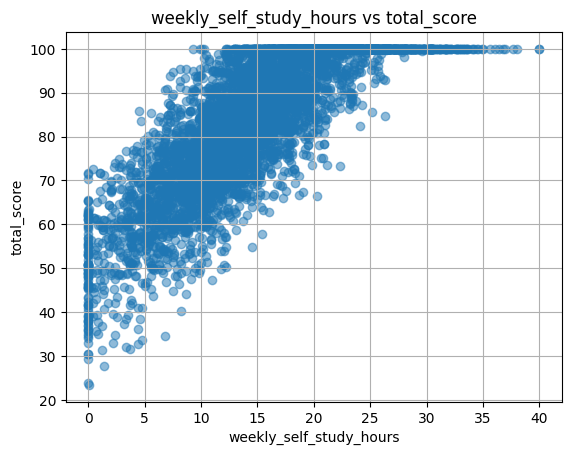

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df_sample["weekly_self_study_hours"], df_sample["total_score"], alpha = 0.5)
plt.title("weekly_self_study_hours vs total_score")
plt.xlabel("weekly_self_study_hours")
plt.ylabel("total_score")
plt.grid(True)
plt.show()

In [ ]:
X = df_sample[["weekly_self_study_hours"]]
Y = df_sample[["total_score"]]
X

,weekly_self_study_hours
585903,30.6
189636,16.6
573977,18.2
535030,12.1
759363,19.8
...,...
316618,13.5
650884,11.4
91774,11.1
888419,20.6


In [ ]:
from sklearn.model_selection import train_test_split
X_train , X_test , Y_train , Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [ ]:
X_test

,weekly_self_study_hours
853448,11.7
871089,11.2
33578,12.2
18733,16.7
724760,21.1
...,...
479720,16.8
187217,16.1
763779,6.6
375325,16.4


In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train, Y_train)

LinearRegression()

In [ ]:
slope = model.coef_[0]
intercept = model.intercept_

In [ ]:
slope

array([1.79703712])

In [ ]:
intercept

array([57.12384727])

In [ ]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({"Actual Score": Y_test[:20].values.flatten(), "Predicted Score" : y_pred[:20].flatten()})

In [ ]:
comparison

,Actual Score,Predicted Score
0,83.5,78.149182
1,69.8,77.250663
2,88.0,79.047700
3,92.3,87.134367
4,100.0,95.041331
5,100.0,105.823553
6,84.3,79.766515
7,100.0,96.838368
8,83.7,94.861627
9,85.9,87.853182


In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(Y_test, y_pred)
print("R-squared:", r2)

R-squared: 0.6663083172438836


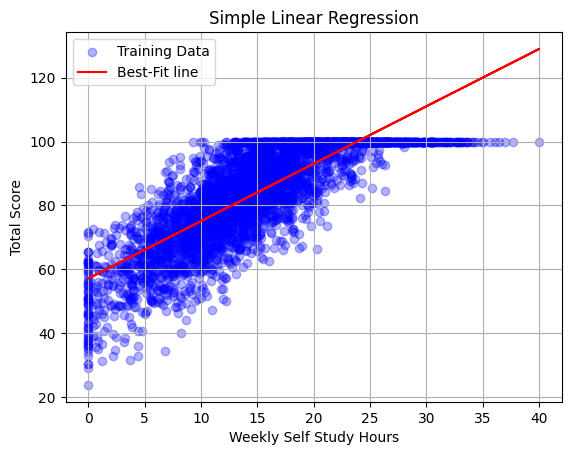

In [ ]:
plt.scatter(X_train , Y_train , alpha = 0.3 , color = "blue" , label = "Training Data")
plt.plot(X_train , model.predict(X_train) , color = "red" , label = "Best-Fit line")

plt.title("Simple Linear Regression")
plt.xlabel("Weekly Self Study Hours")
plt.ylabel("Total Score")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(Y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 7.234319742622014


In [ ]:
# Step 1 - Import all the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [2]:
# Step 2 = Loading the Data

df = pd.read_csv("/content/student_performance (1).csv")

In [ ]:
# Step 3 - Taking a sample of 5000 students

df_sample = df.sample(n = 5000 , random_state = 7)
df_sample

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
330111,330112,11.5,88.2,9.4,66.6,C
663520,663521,15.2,100.0,5.1,81.7,B
525009,525010,0.2,85.6,5.8,35.2,F
199449,199450,15.3,78.9,8.7,74.0,B
978049,978050,14.1,92.7,6.0,84.8,B
...,...,...,...,...,...,...
531144,531145,13.4,75.9,8.4,73.1,B
993441,993442,30.0,94.1,5.8,100.0,A
627450,627451,35.6,73.2,7.6,100.0,A
304819,304820,5.2,92.1,5.1,54.7,D


In [ ]:
# Step 4 - Use all 3 Features

features = ["weekly_self_study_hours", "attendance_percentage", "class_participation"]

x = df_sample[features]
x

,weekly_self_study_hours,attendance_percentage,class_participation
330111,11.5,88.2,9.4
663520,15.2,100.0,5.1
525009,0.2,85.6,5.8
199449,15.3,78.9,8.7
978049,14.1,92.7,6.0
...,...,...,...
531144,13.4,75.9,8.4
993441,30.0,94.1,5.8
627450,35.6,73.2,7.6
304819,5.2,92.1,5.1


In [ ]:
y = df_sample["total_score"]
y

,total_score
330111,66.6
663520,81.7
525009,35.2
199449,74.0
978049,84.8
...,...
531144,73.1
993441,100.0
627450,100.0
304819,54.7


In [ ]:
# Step 5 - Splitting the Data Training 80% - Testing 20%

x_train , x_test , y_train , y_test = train_test_split(x, y , test_size = 0.2 , random_state = 42)

In [ ]:
# Step 6 - Training the Model

model = LinearRegression()
model.fit(x_train , y_train)

LinearRegression()

In [ ]:
coefficients = model.coef_
intercept = model.intercept_

In [ ]:
x

,weekly_self_study_hours,attendance_percentage,class_participation
330111,11.5,88.2,9.4
663520,15.2,100.0,5.1
525009,0.2,85.6,5.8
199449,15.3,78.9,8.7
978049,14.1,92.7,6.0
...,...,...,...
531144,13.4,75.9,8.4
993441,30.0,94.1,5.8
627450,35.6,73.2,7.6
304819,5.2,92.1,5.1


In [ ]:
coefficients

array([ 1.81687239,  0.01922813, -0.02055585])

In [ ]:
# Step 7 - Predict and Test the model

y_pred = model.predict(x_test)

compare = pd.DataFrame({"Actual Score": y_test[:10].values.flatten(), "Predicted Score" : y_pred[:10].flatten()})

In [ ]:
compare

,Actual Score,Predicted Score
0,100.0,82.517367
1,99.1,89.847513
2,83.3,88.523016
3,69.8,79.608214
4,57.6,75.590050
5,87.8,83.639148
6,100.0,111.913205
7,85.3,85.152925
8,88.9,81.793662
9,94.8,93.875039


In [ ]:
comparison

,Actual Score,Predicted Score
0,83.5,78.149182
1,69.8,77.250663
2,88.0,79.047700
3,92.3,87.134367
4,100.0,95.041331
5,100.0,105.823553
6,84.3,79.766515
7,100.0,96.838368
8,83.7,94.861627
9,85.9,87.853182


In [ ]:
r2 = r2_score(y_test , y_pred)

In [ ]:
r2

0.6533031638090047

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 7.325377339455497


In [ ]:
import pandas as pd
df = pd.read_csv("/content/Iris.csv")
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [ ]:
# Logistic Regression model and Decision Tree

# Step 1 - Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


In [ ]:
# Loading the Dataset
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [ ]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [ ]:
df["Species"].value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [ ]:
# Step 3 Prepare the Data
X = df[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]]
Y = df[["Species"]]
Y

,Species
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa
...,...
145,Iris-virginica
146,Iris-virginica
147,Iris-virginica
148,Iris-virginica


In [ ]:
# Split the data into train and test

X_train , X_test , Y_train , Y_test = train_test_split(X  , Y , test_size = 0.2 , random_state = 6)


In [ ]:
X_test.shape

(30, 4)

In [ ]:
# Create the Logistic Regression model

log_reg = LogisticRegression(max_iter = 100)

log_reg.fit(X_train , Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [ ]:
# Decision Tree model

tree_model = DecisionTreeClassifier()

tree_model.fit(X_train , Y_train)

DecisionTreeClassifier()

In [ ]:
# Predictions using both models

y_pred_log = log_reg.predict(X_test)

y_pred_tree = tree_model.predict(X_test)

In [ ]:
# accuracy_log = log_reg.score(X_test , Y_test)
# accuracy_tree = tree_model.score(X_test , Y_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_log = accuracy_score(Y_test , y_pred_log)
accuracy_tree = accuracy_score(Y_test , y_pred_tree)

In [ ]:
print("Model Comparision")
print(f"Logistic Regression Accuracy : {accuracy_log * 100:.2f}%")
print(f"Decision Tree Accuracy : {accuracy_tree * 100:.2f}%")

Model Comparision
Logistic Regression Accuracy : 96.67%
Decision Tree Accuracy : 93.33%


In [ ]:
from sklearn.metrics import classification_report
print("Detailed Report")
print(classification_report(Y_test , y_pred_log , target_names = ["Iris-setosa" , "Iris-versicolor" , "Iris-virginica"]))

Detailed Report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         9
Iris-versicolor       0.91      1.00      0.95        10
 Iris-virginica       1.00      0.91      0.95        11

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30

